In [3]:
pip install praw


  Obtaining dependency information for praw from https://files.pythonhosted.org/packages/73/ca/60ec131c3b43bff58261167045778b2509b83922ce8f935ac89d871bd3ea/praw-7.8.1-py3-none-any.whl.metadata
  Obtaining dependency information for prawcore<3,>=2.4 from https://files.pythonhosted.org/packages/96/5c/8af904314e42d5401afcfaff69940dc448e974f80f7aa39b241a4fbf0cf1/prawcore-2.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for update_checker>=0.18 from https://files.pythonhosted.org/packages/0c/ba/8dd7fa5f0b1c6a8ac62f8f57f7e794160c1f86f31c6d0fb00f582372a3e4/update_checker-0.18.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/189.3 kB ? eta -:--:--
   ------------------------------------ --- 174.1/189.3 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 189.3/189.3 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [36]:
import praw
import pandas as pd
import datetime as dt

# Reddit API credentials 
reddit = praw.Reddit(
    client_id='ydXRFnmf3AqDzF5FZ__ebw',
    client_secret='mORxNFUwlRigEY7X1wxgvU5aDpWe8w',
    user_agent='TrendPredictor/0.1 by Rare-Papaya-7055'
)

subreddits = ['technology', 'startups', 'news', 'science', 'movies']
posts = []


for sub in subreddits:
    for submission in reddit.subreddit(sub).new(limit=500):  
        posts.append([
            submission.id,
            sub,
            submission.title,
            submission.selftext,
            dt.datetime.fromtimestamp(submission.created_utc),
            submission.score,
            submission.num_comments,
            submission.upvote_ratio,
            submission.author.name if submission.author else "deleted",
            submission.link_flair_text,
            submission.is_self
        ])


df = pd.DataFrame(posts, columns=[
    'id', 'subreddit', 'title', 'text', 'created_time', 'upvotes', 'comments',
    'upvote_ratio', 'author', 'flair', 'is_self'
])

df.head()


,id,subreddit,title,text,created_time,upvotes,comments,upvote_ratio,author,flair,is_self
0,1jyegb7,technology,ChatGPT became the most downloaded app globall...,,2025-04-13 14:30:05,0,1,0.41,BalticsFox,Artificial Intelligence,False
1,1jydl8a,technology,More Chaos: Trump Admin Signals New Tariffs on...,,2025-04-13 13:53:42,788,142,0.96,indig0sixalpha,Business,False
2,1jycsik,technology,"Trump Commerce chief fuels tariff confusion, s...",,2025-04-13 13:19:24,801,85,0.96,BreakfastTop6899,Politics,False
3,1jyavem,technology,YouTube considers a daily timer for users look...,,2025-04-13 11:56:49,274,83,0.92,BalticsFox,Social Media,False
4,1jyas6g,technology,US EV Sales Rise As Tesla Sales Fall,,2025-04-13 11:52:51,1018,37,0.98,Wagamaga,Business,False


In [38]:

df['is_viral'] = df['upvotes'] >= 500
df['is_viral'] = df['is_viral'].astype(int)  # convert from bool to int (1 or 0)


df['is_viral'].value_counts()


0    1578
1     685
Name: is_viral, dtype: int64

In [40]:
df['title_length'] = df['title'].apply(lambda x: len(str(x)))


In [41]:
df['text_length'] = df['text'].apply(lambda x: len(str(x)))


In [42]:
df['hour_posted'] = df['created_time'].dt.hour


In [43]:
df['day_of_week'] = df['created_time'].dt.dayofweek
# 0 = Monday, 6 = Sunday


In [44]:
df[['title', 'upvotes', 'is_viral', 'title_length', 'text_length', 'hour_posted', 'day_of_week']].head()


,title,upvotes,is_viral,title_length,text_length,hour_posted,day_of_week
0,ChatGPT became the most downloaded app globall...,0,0,56,0,14,6
1,More Chaos: Trump Admin Signals New Tariffs on...,788,1,81,0,13,6
2,"Trump Commerce chief fuels tariff confusion, s...",801,1,96,0,13,6
3,YouTube considers a daily timer for users look...,274,0,71,0,11,6
4,US EV Sales Rise As Tesla Sales Fall,1018,1,36,0,11,6


In [45]:
pip install textblob


Note: you may need to restart the kernel to use updated packages.


In [46]:
from textblob import TextBlob

df['sentiment_title'] = df['title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
# Range: -1 (negative) to +1 (positive)


In [47]:
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))


In [48]:
df['flair'] = df['flair'].fillna('None')


In [49]:
df['text_empty'] = df['text'].apply(lambda x: 1 if len(str(x).strip()) == 0 else 0)


In [50]:
df.rename(columns={'is_self': 'is_text_post'}, inplace=True)


In [51]:
df.head()

,id,subreddit,title,text,created_time,upvotes,comments,upvote_ratio,author,flair,is_text_post,is_viral,title_length,text_length,hour_posted,day_of_week,sentiment_title,title_word_count,text_empty
0,1jyegb7,technology,ChatGPT became the most downloaded app globall...,,2025-04-13 14:30:05,0,1,0.41,BalticsFox,Artificial Intelligence,False,0,56,0,14,6,0.250000,9,1
1,1jydl8a,technology,More Chaos: Trump Admin Signals New Tariffs on...,,2025-04-13 13:53:42,788,142,0.96,indig0sixalpha,Business,False,1,81,0,13,6,0.318182,13,1
2,1jycsik,technology,"Trump Commerce chief fuels tariff confusion, s...",,2025-04-13 13:19:24,801,85,0.96,BreakfastTop6899,Politics,False,1,96,0,13,6,0.000000,13,1
3,1jyavem,technology,YouTube considers a daily timer for users look...,,2025-04-13 11:56:49,274,83,0.92,BalticsFox,Social Media,False,0,71,0,11,6,0.000000,13,1
4,1jyas6g,technology,US EV Sales Rise As Tesla Sales Fall,,2025-04-13 11:52:51,1018,37,0.98,Wagamaga,Business,False,1,36,0,11,6,0.000000,8,1


In [52]:
df.columns

Index(['id', 'subreddit', 'title', 'text', 'created_time', 'upvotes',
       'comments', 'upvote_ratio', 'author', 'flair', 'is_text_post',
       'is_viral', 'title_length', 'text_length', 'hour_posted', 'day_of_week',
       'sentiment_title', 'title_word_count', 'text_empty'],
      dtype='object')

In [53]:
df.isnull().sum()

id                  0
subreddit           0
title               0
text                0
created_time        0
upvotes             0
comments            0
upvote_ratio        0
author              0
flair               0
is_text_post        0
is_viral            0
title_length        0
text_length         0
hour_posted         0
day_of_week         0
sentiment_title     0
title_word_count    0
text_empty          0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                2263 non-null   object        
 1   subreddit         2263 non-null   object        
 2   title             2263 non-null   object        
 3   text              2263 non-null   object        
 4   created_time      2263 non-null   datetime64[ns]
 5   upvotes           2263 non-null   int64         
 6   comments          2263 non-null   int64         
 7   upvote_ratio      2263 non-null   float64       
 8   author            2263 non-null   object        
 9   flair             2263 non-null   object        
 10  is_text_post      2263 non-null   bool          
 11  is_viral          2263 non-null   int32         
 12  title_length      2263 non-null   int64         
 13  text_length       2263 non-null   int64         
 14  hour_posted       2263 n

In [55]:
df['flair'] = df['flair'].fillna('None')  # just in case
df = pd.get_dummies(df, columns=['flair'], prefix='flair')


In [56]:
df = pd.get_dummies(df, columns=['subreddit'], prefix='subreddit')


In [57]:
columns_to_drop = ['id', 'title', 'text', 'created_time']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')


In [58]:
pip install seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.


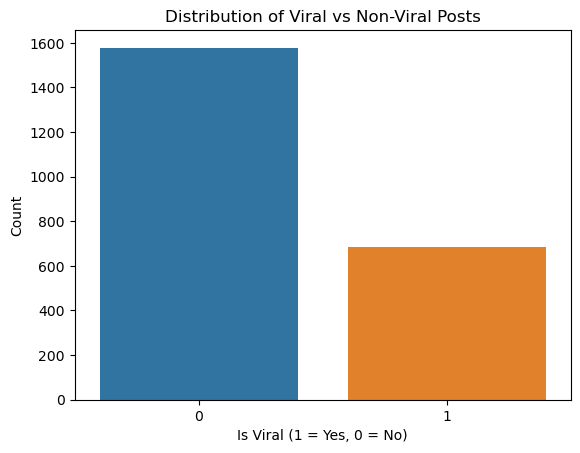

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_cleaned, x='is_viral')
plt.title('Distribution of Viral vs Non-Viral Posts')
plt.xlabel('Is Viral (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


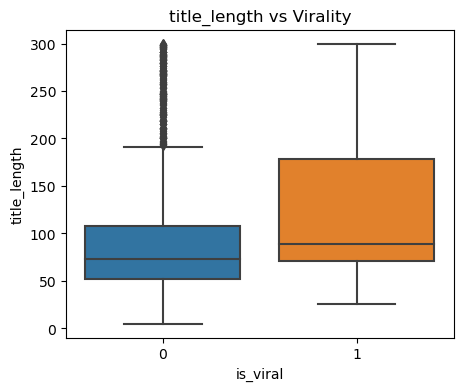

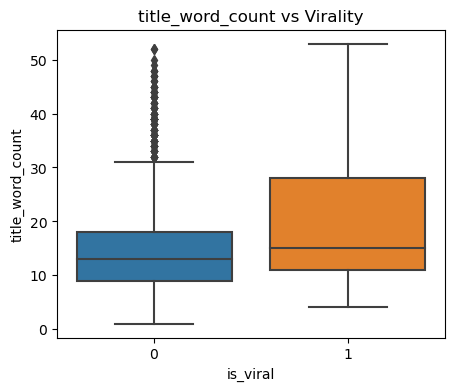

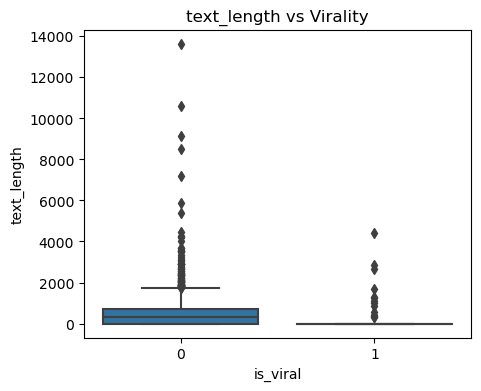

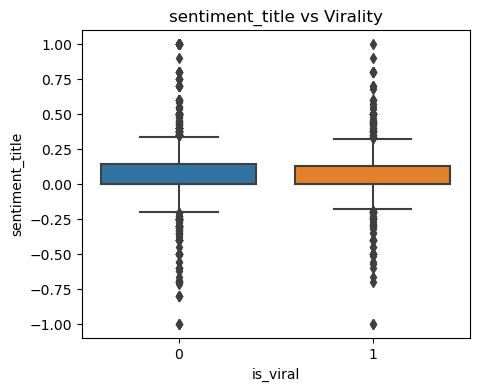

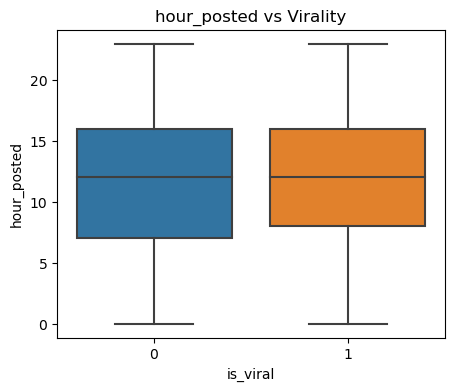

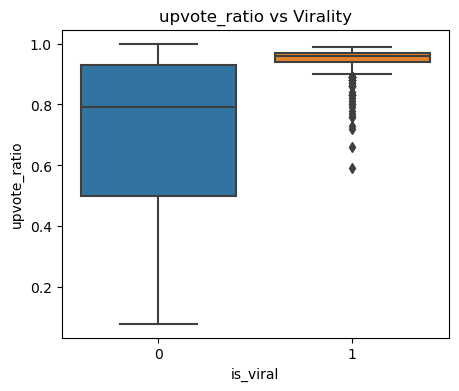

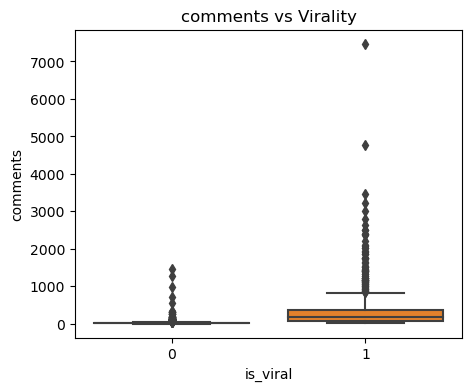

In [64]:
numeric_features = [
    'title_length', 'title_word_count', 'text_length',
    'sentiment_title', 'hour_posted', 'upvote_ratio', 'comments'
]

for feature in numeric_features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df_cleaned, x='is_viral', y=feature)
    plt.title(f'{feature} vs Virality')
    plt.show()


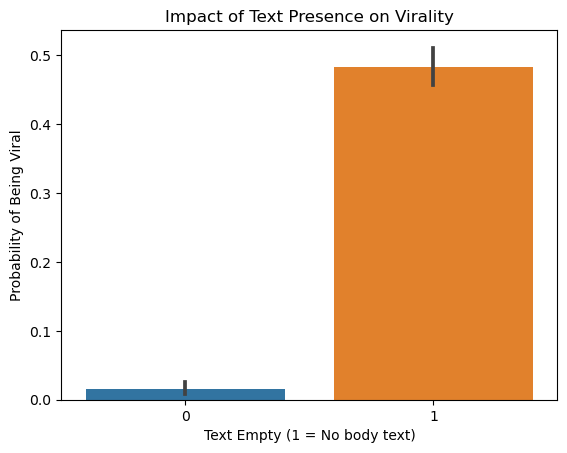

In [61]:
sns.barplot(data=df_cleaned, x='text_empty', y='is_viral')
plt.title('Impact of Text Presence on Virality')
plt.xlabel('Text Empty (1 = No body text)')
plt.ylabel('Probability of Being Viral')
plt.show()


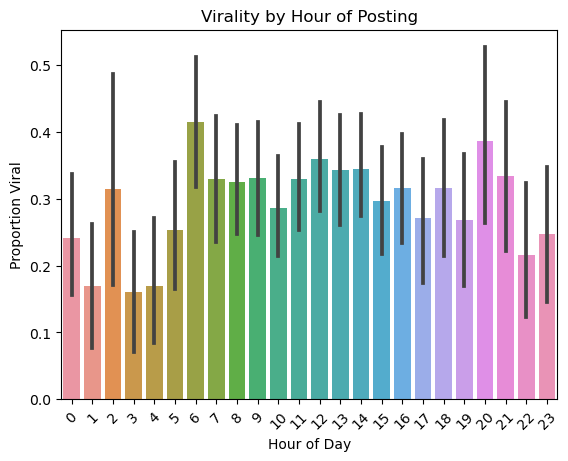

In [62]:
sns.barplot(data=df_cleaned, x='hour_posted', y='is_viral')
plt.title('Virality by Hour of Posting')
plt.xlabel('Hour of Day')
plt.ylabel('Proportion Viral')
plt.xticks(rotation=45)
plt.show()


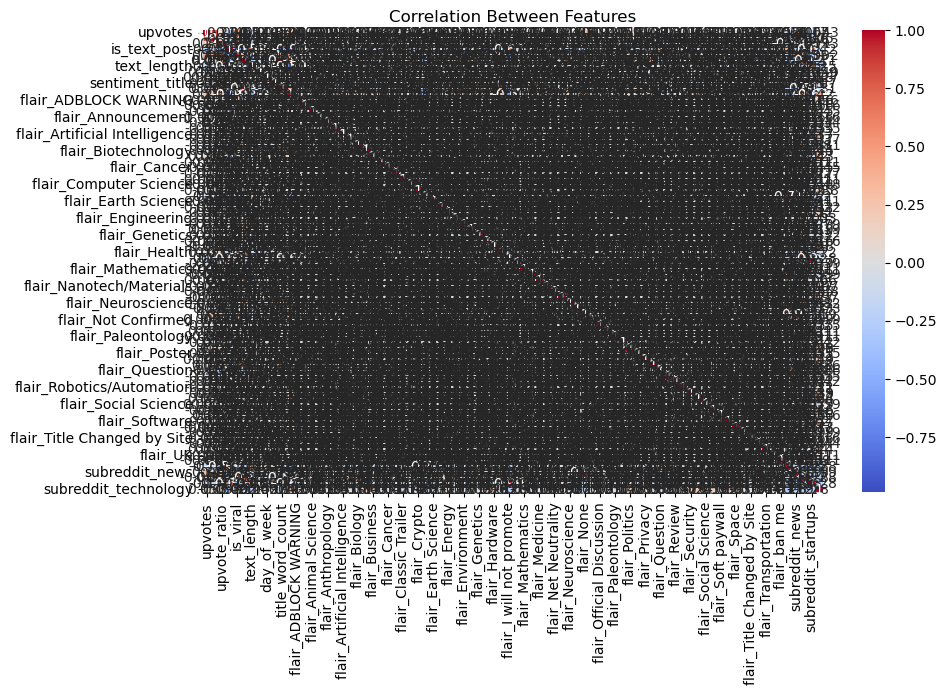

In [63]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Features')
plt.show()


In [69]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_cleaned.drop(columns=['is_viral','author'])
y = df_cleaned['is_viral']

# Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train model
lr = LogisticRegression(max_iter=3000, class_weight='balanced')  # 'balanced' to handle class imbalance
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)


In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       316
           1       1.00      1.00      1.00       137

    accuracy                           1.00       453
   macro avg       1.00      1.00      1.00       453
weighted avg       1.00      1.00      1.00       453



In [73]:
y_train_pred = lr.predict(X_train)

from sklearn.metrics import classification_report

print("Training Set Performance:\n")
print(classification_report(y_train, y_train_pred))


Training Set Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1262
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1810
   macro avg       1.00      1.00      1.00      1810
weighted avg       1.00      1.00      1.00      1810



In [96]:
#Removing the data leakage factors
leak_features = ['upvotes', 'comments', 'upvote_ratio']
X_reduced = X.drop(columns=leak_features, errors='ignore')


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)


In [76]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000, class_weight='balanced')
lr.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=3000)

In [77]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.77      0.83       316
           1       0.60      0.80      0.69       137

    accuracy                           0.78       453
   macro avg       0.75      0.78      0.76       453
weighted avg       0.81      0.78      0.78       453



since upvotes, comments,upvote_ratio directly help the model in predicting using the given values it was not serving its purpose so therefore we removed those columns and then ran the model

In [78]:
#Lets try with Random Forest Classifier

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train the model
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Performance:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       316
           1       0.73      0.60      0.66       137

    accuracy                           0.81       453
   macro avg       0.78      0.75      0.76       453
weighted avg       0.80      0.81      0.80       453



In [80]:
#Lets use XGBoost 

In [81]:
pip install xgboost


  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/5e/03/15cd49e855c62226ecf1831bbe4c8e73a4324856077a23c495538a36e557/xgboost-3.0.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.2/150.0 MB 3.5 MB/s eta 0:00:43
   ---------------------------------------- 0.7/150.0 MB 7.8 MB/s eta 0:00:20
    --------------------------------------- 2.4/150.0 MB 14.9 MB/s eta 0:00:10
   - -------------------------------------- 4.9/150.0 MB 24.3 MB/s eta 0:00:06
   -- ------------------------------------- 7.6/150.0 MB 30.2 MB/s eta 0:00:05
   -- ------------------------------------- 9.5/150.0 MB 33.5 MB/s eta 0:00:05
   --- ------------------------------------ 11.6/150.0 MB 50.4 MB/s eta 0:00:03
   --- ------------------------------------ 14.0/150.0 MB 50.4 MB/s eta 0:00:03
   ---- ----------------------------------- 16.0/150.0 MB 50.4 MB/s eta 0:00:03
   ---- ----

In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Performance:\n")
print(classification_report(y_test, y_pred_xgb))


C:\Users\kavya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:10:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance:

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       316
           1       0.67      0.62      0.65       137

    accuracy                           0.79       453
   macro avg       0.76      0.75      0.75       453
weighted avg       0.79      0.79      0.79       453



Among Random Forest,XGBoost and Logistic Regression, Random Forest performed the best with an accuracy of 81%

Lets perform Feature Importance for Random Forest

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names and their importance scores
importances = rf.feature_importances_
features = X_train.columns

# Create a DataFrame
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort features by importance
feat_df = feat_df.sort_values(by='Importance', ascending=False)


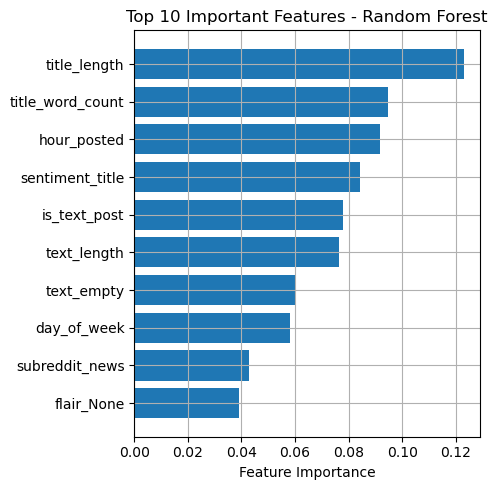

In [86]:
# Plotting top 10 features
top_n = 10

plt.figure(figsize=(5, 5))
plt.barh(feat_df['Feature'][:top_n][::-1], feat_df['Importance'][:top_n][::-1])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Important Features - Random Forest')
plt.grid(True)
plt.tight_layout()
plt.show()


The top 10 most important features indicate that title characteristics (length, word count, sentiment) and posting behavior (hour, day, post type) significantly influence virality. These insights suggest that how and when content is shared plays a crucial role in its potential to go viral.

# A/B TESTING

Hypothesis 1)
Posts with a long title (≥80 characters) are more likely to go viral than short ones.

In [87]:
import scipy.stats as stats

#Defining A and B groups
df_cleaned['title_long'] = df_cleaned['title_length'] >= 80


group_A = df_cleaned[df_cleaned['title_long'] == False]['is_viral']
group_B = df_cleaned[df_cleaned['title_long'] == True]['is_viral']


contingency_table = pd.crosstab(df_cleaned['title_long'], df_cleaned['is_viral'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test p-value:", p)


Chi-square test p-value: 7.050827684769331e-16


The A/B test comparing long titles (≥80 characters) and short titles revealed a significant difference in virality rates (p < 0.001). This suggests that longer titles are more likely to go viral and may improve engagement.

Hypothesis 2) Text posts (vs. link posts) are more likely to go viral

In [88]:
contingency_text = pd.crosstab(df_cleaned['is_text_post'], df_cleaned['is_viral'])
print(contingency_text)


is_viral        0    1
is_text_post          
False         729  673
True          849   12


In [89]:
from scipy.stats import chi2_contingency

chi2_text, p_text, dof, expected = chi2_contingency(contingency_text)
print("Text vs Link - Chi-square test p-value:", p_text)


Text vs Link - Chi-square test p-value: 6.241820558482473e-121


The A/B test comparing text and link posts showed a highly significant relationship with virality (p < 0.001), indicating that text-based posts are far more likely to go viral than link-based ones.

Hypothesis 3) 
Posts with a positive sentiment in their title are more likely to go viral than those with negative sentiment.

Group A: Negative or neutral sentiment (sentiment_title ≤ 0)

Group B: Positive sentiment (sentiment_title > 0)

In [90]:
df_cleaned['positive_title'] = df_cleaned['sentiment_title'] > 0


In [91]:
contingency_sentiment = pd.crosstab(df_cleaned['positive_title'], df_cleaned['is_viral'])
print(contingency_sentiment)


is_viral          0    1
positive_title          
False           994  400
True            584  285


In [92]:
chi2_sent, p_sent, dof, expected = chi2_contingency(contingency_sentiment)
print("Positive vs Negative Sentiment - Chi-square test p-value:", p_sent)


Positive vs Negative Sentiment - Chi-square test p-value: 0.043520490491080324


The A/B test comparing posts with positive vs. non-positive title sentiment yielded a statistically significant result (p = 0.043), suggesting that title positivity may influence virality. However, the marginal significance indicates this effect could be subtle.

Hypothesis 4) Posts made after 12 PM are more likely to go viral than those posted before 12 PM.

In [93]:
# Group A: before 12 PM → hour < 12
# Group B: after or at 12 PM → hour >= 12
df_cleaned['after_noon'] = df_cleaned['hour_posted'] >= 12


In [94]:
contingency_time = pd.crosstab(df_cleaned['after_noon'], df_cleaned['is_viral'])
print(contingency_time)


is_viral      0    1
after_noon          
False       749  304
True        829  381


In [95]:
chi2_time, p_time, dof, expected = chi2_contingency(contingency_time)
print("Before vs After 12 PM - Chi-square test p-value:", p_time)


Before vs After 12 PM - Chi-square test p-value: 0.19151247294673002


The A/B test comparing virality of posts before and after 12 PM resulted in a non-significant p-value (p = 0.19), indicating that time of posting in relation to noon does not significantly influence virality.